In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('smart_meter_data.csv')
print("Dataset shape:", df.shape)

Dataset shape: (525600, 6)


In [2]:
# Basic info about the dataset
print("\n=== DATASET INFO ===")
print(df.info())
print("\n=== FIRST 5 ROWS ===")
print(df.head())

# Convert datetime column
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Basic statistics
print("\n=== DESCRIPTIVE STATISTICS ===")
print(df[['daily_consumption_load', 'energy_supplied', 'energy_billed']].describe())

# Check for missing values
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())


=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   datetime                525600 non-null  object 
 1   msn                     525600 non-null  object 
 2   location                525600 non-null  object 
 3   daily_consumption_load  525600 non-null  float64
 4   energy_supplied         525600 non-null  float64
 5   energy_billed           525600 non-null  float64
dtypes: float64(3), object(3)
memory usage: 24.1+ MB
None

=== FIRST 5 ROWS ===
              datetime       msn location  daily_consumption_load  \
0  2021-01-01 00:00:00  ACE43B7D  Chennai                    2.59   
1  2021-01-01 00:15:00  ACE43B7D  Chennai                    1.78   
2  2021-01-01 00:30:00  ACE43B7D  Chennai                    2.59   
3  2021-01-01 00:45:00  ACE43B7D  Chennai                    2.45   
4  2021-01-

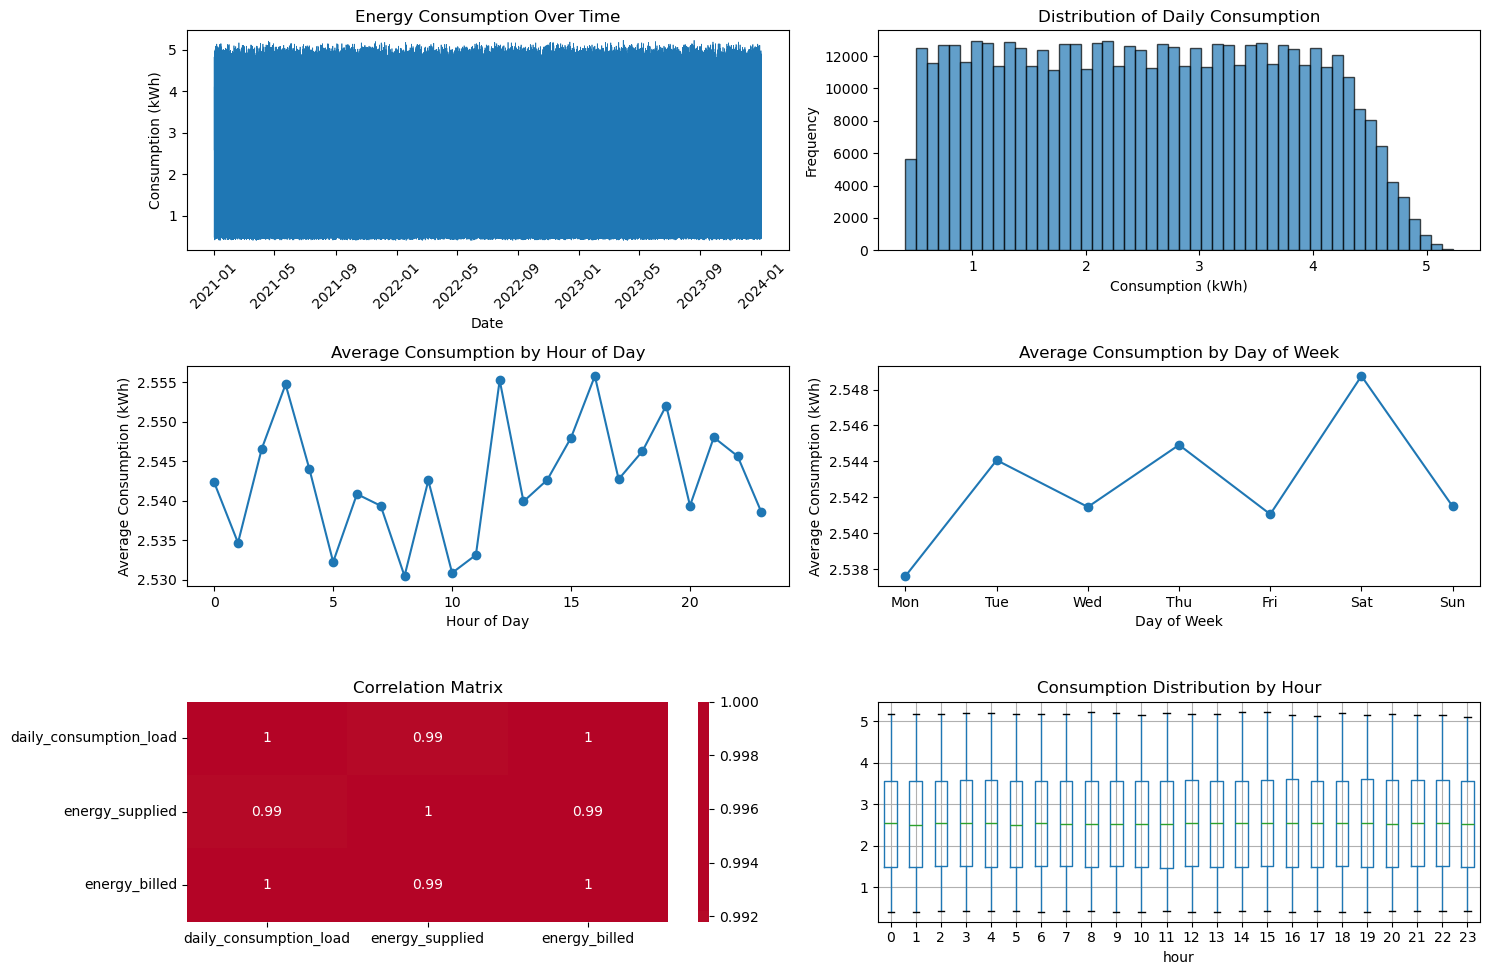

In [3]:
# Time series visualization
plt.figure(figsize=(15, 10))

# Plot 1: Overall consumption trend
plt.subplot(3, 2, 1)
plt.plot(df['datetime'], df['daily_consumption_load'], linewidth=0.5)
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.xticks(rotation=45)

# Plot 2: Distribution of consumption
plt.subplot(3, 2, 2)
plt.hist(df['daily_consumption_load'], bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Daily Consumption')
plt.xlabel('Consumption (kWh)')
plt.ylabel('Frequency')

# Plot 3: Daily patterns (aggregate by hour)
plt.subplot(3, 2, 3)
df['hour'] = df['datetime'].dt.hour
hourly_avg = df.groupby('hour')['daily_consumption_load'].mean()
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Consumption by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Consumption (kWh)')

# Plot 4: Day of week patterns
plt.subplot(3, 2, 4)
df['dayofweek'] = df['datetime'].dt.dayofweek
daily_avg = df.groupby('dayofweek')['daily_consumption_load'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.plot(days, daily_avg.values, marker='o')
plt.title('Average Consumption by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Consumption (kWh)')

# Plot 5: Correlation heatmap
plt.subplot(3, 2, 5)
correlation_matrix = df[['daily_consumption_load', 'energy_supplied', 'energy_billed']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')

# Plot 6: Box plot by hour
plt.subplot(3, 2, 6)
df.boxplot(column='daily_consumption_load', by='hour', ax=plt.gca())
plt.title('Consumption Distribution by Hour')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

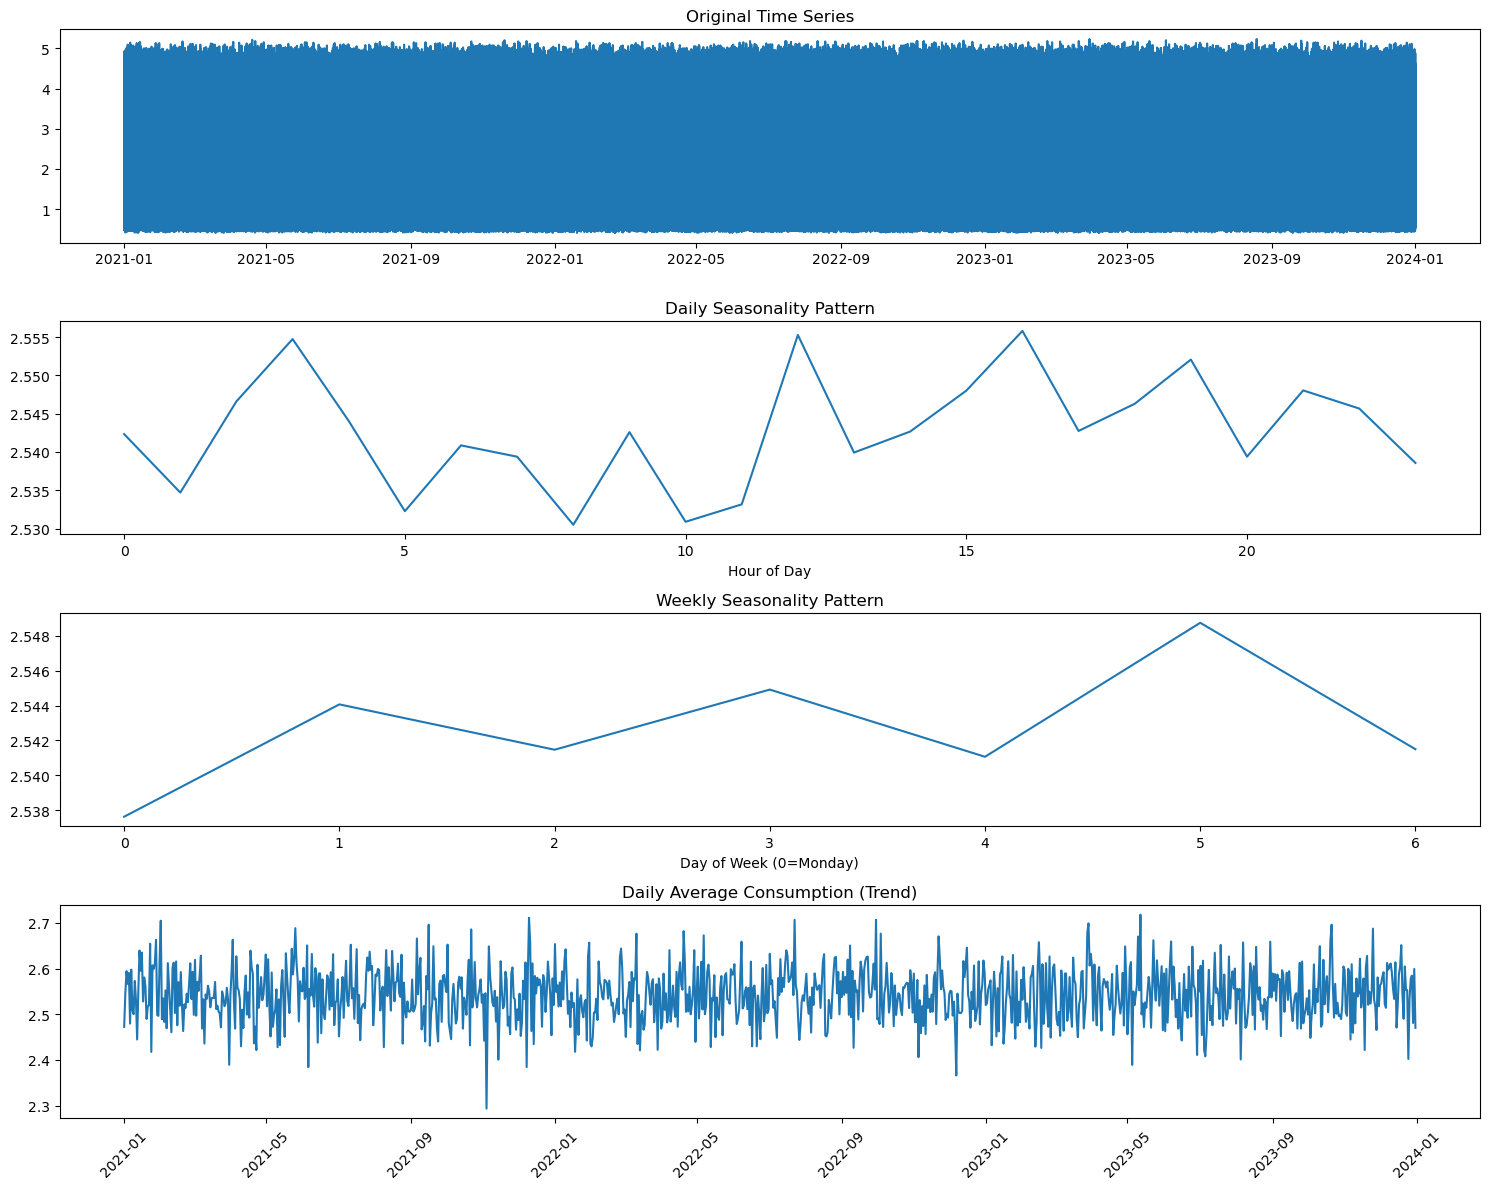

In [4]:
# Seasonal decomposition (simplified)
def plot_seasonal_decomposition(df):
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    
    # Original series
    axes[0].plot(df['datetime'], df['daily_consumption_load'])
    axes[0].set_title('Original Time Series')
    
    # Daily seasonality
    hourly_pattern = df.groupby('hour')['daily_consumption_load'].mean()
    axes[1].plot(hourly_pattern.index, hourly_pattern.values)
    axes[1].set_title('Daily Seasonality Pattern')
    axes[1].set_xlabel('Hour of Day')
    
    # Weekly seasonality
    weekly_pattern = df.groupby('dayofweek')['daily_consumption_load'].mean()
    axes[2].plot(weekly_pattern.index, weekly_pattern.values)
    axes[2].set_title('Weekly Seasonality Pattern')
    axes[2].set_xlabel('Day of Week (0=Monday)')
    
    # Residual (simplified)
    daily_avg = df.groupby(df['datetime'].dt.date)['daily_consumption_load'].mean()
    axes[3].plot(daily_avg.index, daily_avg.values)
    axes[3].set_title('Daily Average Consumption (Trend)')
    axes[3].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_seasonal_decomposition(df)

In [5]:
# Prepare data for LSTM
def create_sequences(data, sequence_length=24):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length), 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

# Use only consumption data for univariate forecasting
data = df['daily_consumption_load'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original data shape: {data.shape}")
print(f"Scaled data shape: {scaled_data.shape}")

# Split data into train/test (80/20 split)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

# Create sequences
sequence_length = 24 * 4  # 24 hours (4 readings per hour * 24 = 96 sequences for one day)
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

# Reshape for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Original data shape: (525600, 1)
Scaled data shape: (525600, 1)
Train size: 420480
Test size: 105120
X_train shape: (420384, 96, 1)
y_train shape: (420384,)
X_test shape: (105024, 96, 1)
y_test shape: (105024,)


In [10]:
def create_ultra_simple_lstm(sequence_length):
    model = Sequential([
        LSTM(16, input_shape=(sequence_length, 1)),  # Only 1 LSTM layer
        Dense(1)  # Direct output
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create model
model = create_ultra_simple_lstm(sequence_length)
print(model.summary())

# Train quickly
history = model.fit(
    X_train, y_train,
    batch_size=128,    # Large batch = faster
    epochs=10,         # Few epochs
    validation_data=(X_test, y_test),
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,169 (4.57 KB)

 Trainable params: 1,169 (4.57 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 52s 16ms/step - loss: 0.0648 - mae: 0.2190 - val_loss: 0.0633 - val_mae: 0.2171
Epoch 2/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 121s 37ms/step - loss: 0.0635 - mae: 0.2175 - val_loss: 0.0631 - val_mae: 0.2167
Epoch 3/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 62s 19ms/step - loss: 0.0635 - mae: 0.2175 - val_loss: 0.0632 - val_mae: 0.2168
Epoch 4/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 83s 25ms/step - loss: 0.0635 - mae: 0.2174 - val_loss: 0.0630 - val_mae: 0.2167
Epoch 5/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 144s 44ms/step - loss: 0.0635 - mae: 0.2174 - val_loss: 0.0630 - val_mae: 0.2167
Epoch 6/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 132s 40ms/step - loss: 0.0635 - mae: 0.2174 - val_loss: 0.0631 - val_mae: 0.2167
Epoch 7/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 146s 44ms/step - loss: 0.0634 - mae: 0.2174 - val_loss: 0.0631 - val_mae: 0.2167
Epoch 8/10
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 133s 40ms/step - loss: 0.0635 - mae: 0.2174 - val_loss: 0.0631 - val_mae: 0.2167
Epoch 9/10
328

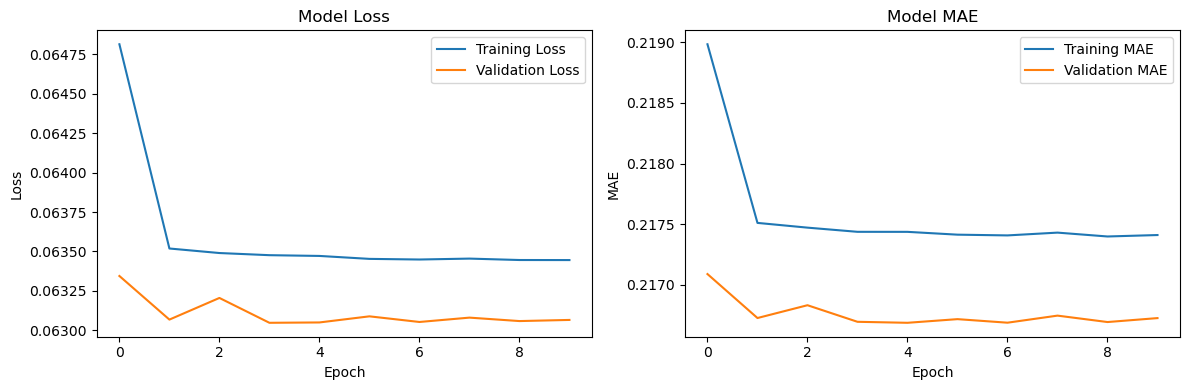

13137/13137 ━━━━━━━━━━━━━━━━━━━━ 54s 4ms/step
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step

=== MODEL PERFORMANCE ===
Train MAE: 1.0479
Test MAE: 1.0446
Train RMSE: 1.2139
Test RMSE: 1.2104


In [11]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Calculate metrics
train_mae = mean_absolute_error(y_train_actual, train_predict)
test_mae = mean_absolute_error(y_test_actual, test_predict)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

print(f"\n=== MODEL PERFORMANCE ===")
print(f"Train MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

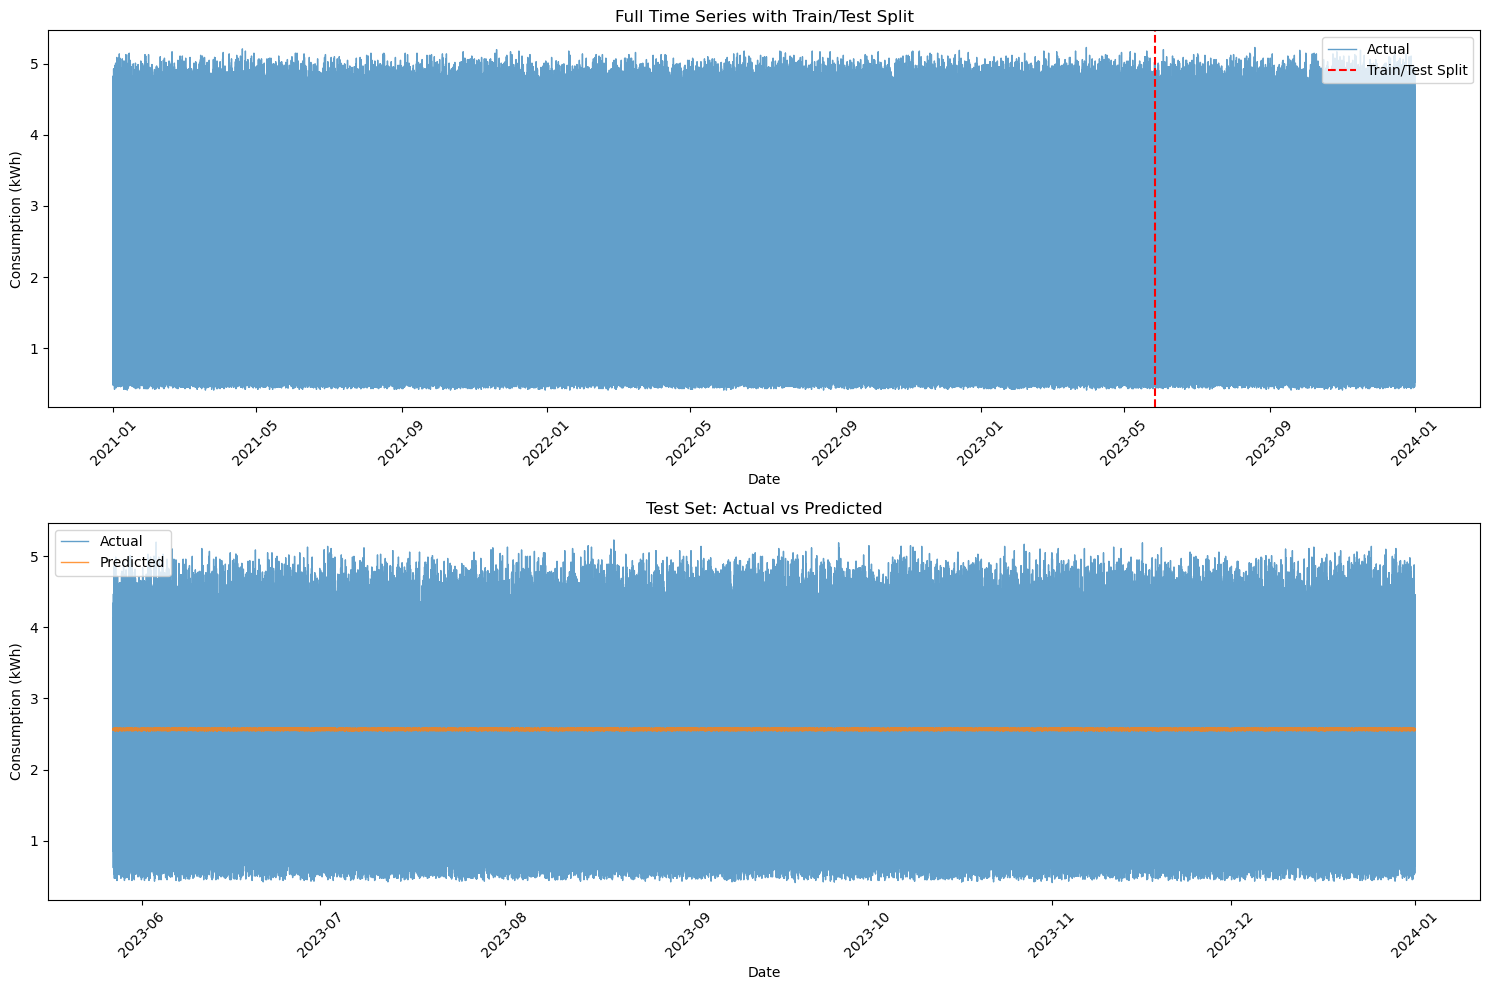

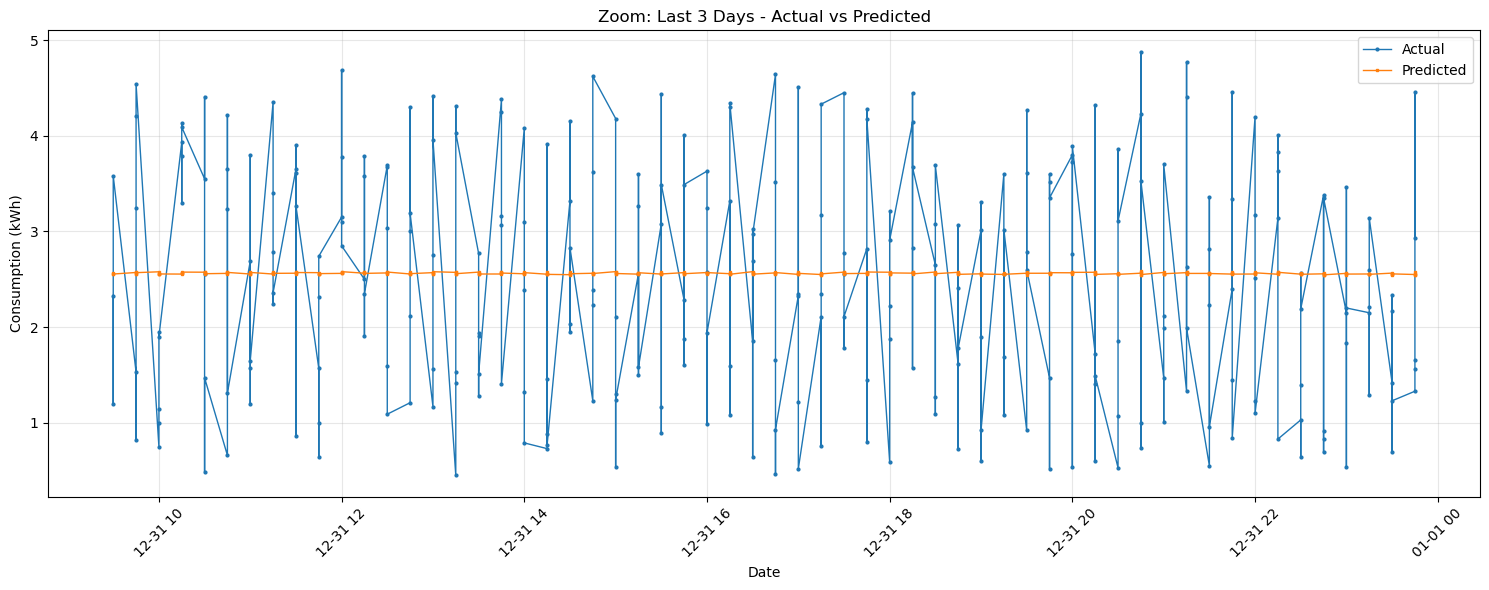

In [12]:
# Create time indices for plotting
train_indices = range(sequence_length, sequence_length + len(train_predict))
test_indices = range(train_size + sequence_length, train_size + sequence_length + len(test_predict))

# Plot predictions vs actual
plt.figure(figsize=(15, 10))

# Full series with train/test split
plt.subplot(2, 1, 1)
plt.plot(df['datetime'], df['daily_consumption_load'], label='Actual', alpha=0.7, linewidth=1)
plt.axvline(x=df['datetime'].iloc[train_size], color='red', linestyle='--', label='Train/Test Split')
plt.title('Full Time Series with Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.xticks(rotation=45)

# Test set predictions
plt.subplot(2, 1, 2)
test_dates = df['datetime'].iloc[test_indices]
plt.plot(test_dates, y_test_actual, label='Actual', alpha=0.7, linewidth=1)
plt.plot(test_dates, test_predict, label='Predicted', alpha=0.8, linewidth=1)
plt.title('Test Set: Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Zoom in on a specific period (last 3 days of test set)
zoom_days = 3
zoom_points = zoom_days * 24 * 4  # 4 readings per hour

if len(test_predict) > zoom_points:
    plt.figure(figsize=(15, 6))
    
    zoom_actual = y_test_actual[-zoom_points:]
    zoom_predicted = test_predict[-zoom_points:]
    zoom_dates = test_dates[-zoom_points:]
    
    plt.plot(zoom_dates, zoom_actual, label='Actual', marker='o', markersize=2, linewidth=1)
    plt.plot(zoom_dates, zoom_predicted, label='Predicted', marker='s', markersize=2, linewidth=1)
    plt.title(f'Zoom: Last {zoom_days} Days - Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Consumption (kWh)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

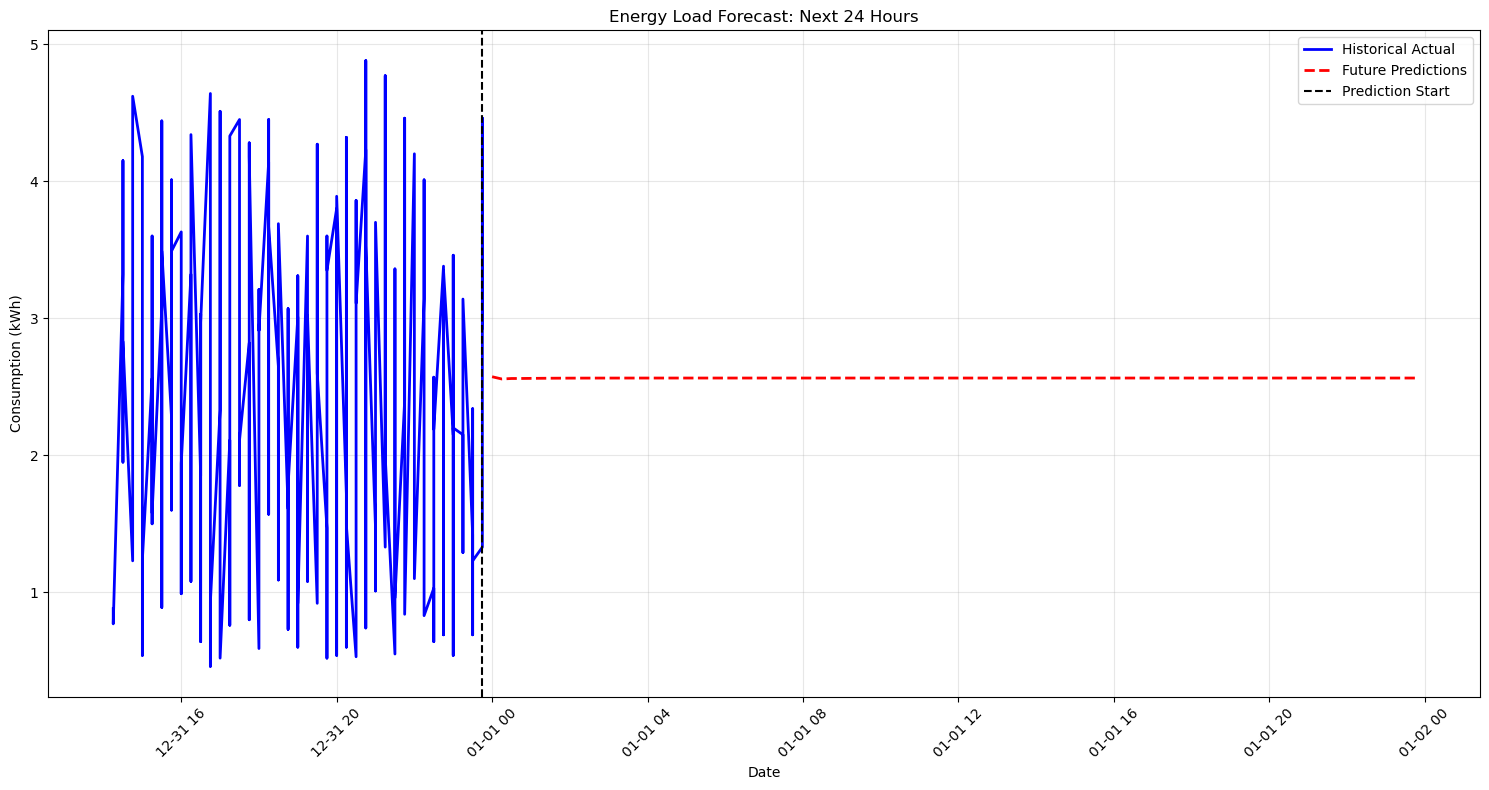


=== FUTURE PREDICTIONS SUMMARY ===
Forecast period: 24 hours (96 readings)
Average predicted consumption: 2.56 kWh
Maximum predicted consumption: 2.57 kWh
Minimum predicted consumption: 2.56 kWh


In [13]:
# Function to predict future values
def predict_future(model, last_sequence, steps=24):
    future_predictions = []
    current_sequence = last_sequence.copy()
    
    for _ in range(steps):
        # Predict next value
        next_pred = model.predict(current_sequence.reshape(1, sequence_length, 1), verbose=0)
        future_predictions.append(next_pred[0, 0])
        
        # Update sequence (remove first, add prediction)
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = next_pred[0, 0]
    
    return np.array(future_predictions)

# Get the last sequence from test data
last_sequence = X_test[-1].flatten()

# Predict next 24 hours (96 readings)
future_steps = 24 * 4
future_predictions_scaled = predict_future(model, last_sequence, future_steps)
future_predictions = scaler.inverse_transform(future_predictions_scaled.reshape(-1, 1))

# Create future dates
last_date = df['datetime'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(minutes=15), 
                           periods=future_steps, freq='15min')

# Plot future predictions
plt.figure(figsize=(15, 8))

# Last week of actual data + future predictions
lookback_days = 2
lookback_points = lookback_days * 24 * 4

actual_dates = df['datetime'].iloc[-lookback_points:]
actual_values = df['daily_consumption_load'].iloc[-lookback_points:]

plt.plot(actual_dates, actual_values, label='Historical Actual', color='blue', linewidth=2)
plt.plot(future_dates, future_predictions, label='Future Predictions', color='red', linewidth=2, linestyle='--')
plt.axvline(x=last_date, color='black', linestyle='--', label='Prediction Start')
plt.title(f'Energy Load Forecast: Next {future_steps//4} Hours')
plt.xlabel('Date')
plt.ylabel('Consumption (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\n=== FUTURE PREDICTIONS SUMMARY ===")
print(f"Forecast period: {future_steps//4} hours ({future_steps} readings)")
print(f"Average predicted consumption: {future_predictions.mean():.2f} kWh")
print(f"Maximum predicted consumption: {future_predictions.max():.2f} kWh")
print(f"Minimum predicted consumption: {future_predictions.min():.2f} kWh")

In [14]:
print("\n" + "="*50)
print("ENERGY LOAD FORECASTING - KEY INSIGHTS")
print("="*50)

# Peak consumption analysis
peak_hour = hourly_avg.idxmax()
peak_consumption = hourly_avg.max()
print(f"Peak consumption hour: {peak_hour}:00 ({peak_consumption:.2f} kWh)")

# Daily patterns
daily_avg_consumption = df['daily_consumption_load'].mean()
print(f"Average 15-min consumption: {daily_avg_consumption:.2f} kWh")

# Model performance summary
print(f"\nModel Performance:")
print(f"Test MAE: {test_mae:.4f} kWh ({(test_mae/daily_avg_consumption)*100:.1f}% of average)")
print(f"Test RMSE: {test_rmse:.4f} kWh")

# Seasonality insights
print(f"\nSeasonality Patterns:")
print(f"Highest consumption day: {days[daily_avg.idxmax()]}")
print(f"Lowest consumption day: {days[daily_avg.idxmin()]}")

# Data quality
print(f"\nData Quality:")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Total readings: {len(df):,}")
print(f"Data frequency: 15-minute intervals")


ENERGY LOAD FORECASTING - KEY INSIGHTS
Peak consumption hour: 16:00 (2.56 kWh)
Average 15-min consumption: 2.54 kWh

Model Performance:
Test MAE: 1.0446 kWh (41.1% of average)
Test RMSE: 1.2104 kWh

Seasonality Patterns:
Highest consumption day: Sat
Lowest consumption day: Mon

Data Quality:
Date range: 2021-01-01 00:00:00 to 2023-12-31 23:45:00
Total readings: 525,600
Data frequency: 15-minute intervals
